<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل پانزدهم: یادگیری تجمیعی: ترکیب مدل‌ها برای بهبود مدل‌ها</h2>
</div>

<div dir="rtl" align="right">

# مثال تکمیلی رگرسیون با جنگل تصادفی

اثر افزایش تعداد درخت‌ها را روی همان ده ردیف حقوق مشاهده می‌کنیم. برآوردهای ۱۰، ۱۰۰ و ۳۰۰ درخت کنار هم قرار می‌گیرند.

</div>

<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>

In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. خواندن دادهٔ حقوق

Level سطح شغلی است، نه تعداد سال‌های سابقه. داده فقط ده ردیف دارد؛ این مثال شکل برازش را نشان می‌دهد و آزمون مستقلی برای تعمیم ندارد.

</div>

In [2]:
# خواندن دادهٔ حقوق
data = pd.read_csv(DATA / "Position_Salaries.csv")
X = data[["Level"]].to_numpy()
y = data["Salary"].to_numpy()
grid = np.arange(float(X.min()), float(X.max()) + 0.01, 0.01).reshape(-1, 1)
display(data)

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


<div dir="rtl" align="right">

## 2. مقایسهٔ تعداد درخت‌ها

تغییر برآورد با افزایش درخت‌ها به‌تنهایی اثبات نمی‌کند که برآورد دقیق‌تر شده است؛ مقدار واقعی سطح ۶٫۵ در فایل وجود ندارد.

</div>

,Trees,Estimate 6.5
0,10,167000.00
1,100,158300.00
2,300,160333.33


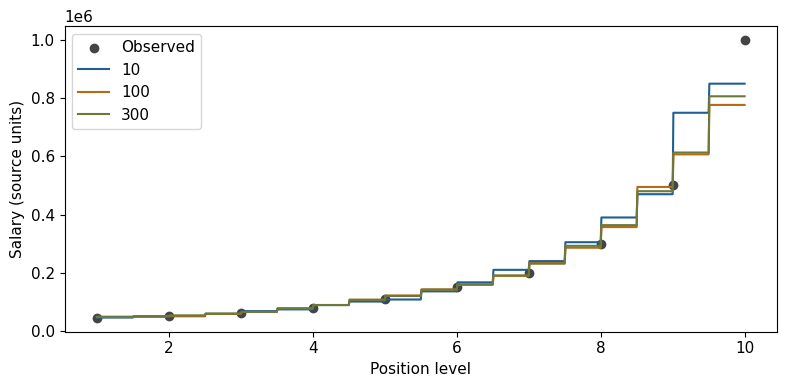

In [3]:
# مقایسهٔ تعداد درخت‌ها
from sklearn.ensemble import RandomForestRegressor
rows = []
plt.scatter(X[:, 0], y, color="#444444", label="Observed")
for trees, color in [(10, "#215e91"), (100, "#b46b12"), (300, "#6b793e")]:
    model = RandomForestRegressor(n_estimators=trees, random_state=0)
    model.fit(X, y)
    rows.append({"Trees": trees, "Estimate 6.5": model.predict([[6.5]])[0]})
    plt.plot(grid[:, 0], model.predict(grid), color=color, label=str(trees))
display(pd.DataFrame(rows).round(2))
plt.xlabel("Position level")
plt.ylabel("Salary (source units)")
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی
این مقایسه دربارهٔ شکل برازش و حساسیت به تعداد درخت‌هاست. دادهٔ آزمون مستقل ندارد و رتبه‌بندی دقت سه مدل از آن ممکن نیست.

</div>

<div dir="rtl" align="right">

## مأخذ مثال
مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>